In [ ]:
import pandas as pd 
import warnings
warnings.filterwarnings("ignore")
pd.plotting.register_matplotlib_converters()
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
sns.set_style("dark")
sns.set_palette("viridis")

<div id="1" style="background-color: #1a1a1a; padding: 10px; border-radius: 10px; border: 2px solid black;">
    <h1 style="font-family:  'Garamond', 'Lucida Sans', sans-serif; text-align: center; color: #fff; font-weight: bold; font-size: 42px;">
    Dataset Overview
    </h1>
    <a class="anchor"  id="chapter1"></a>
</div>

In [18]:
# sample_data=pd.read_csv("/kaggle/input/playground-series-s4e1/sample_submission.csv")
train_data=pd.read_csv("../data/train.csv",index_col="id")
test_data=pd.read_csv("../data/test.csv",index_col="id")


In [19]:
# Binary flags: ensure int (0/1) not float
for col in ("HasCrCard", "IsActiveMember"):
    if col in train_data.columns:
        train_data[col] = train_data[col].astype(int)
    if col in test_data.columns:
        test_data[col] = test_data[col].astype(int)

In [20]:
train_data.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
id,,,,,,,,,,,,,
0,15674932,Okwudilichukwu,668,France,Male,33.0,3,0.00,2,1,0,181449.97,0
1,15749177,Okwudiliolisa,627,France,Male,33.0,1,0.00,2,1,1,49503.50,0
2,15694510,Hsueh,678,France,Male,40.0,10,0.00,2,1,0,184866.69,0
3,15741417,Kao,581,France,Male,34.0,2,148882.54,1,1,1,84560.88,0
4,15766172,Chiemenam,716,Spain,Male,33.0,5,0.00,2,1,1,15068.83,0


In [21]:
test_data.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
id,,,,,,,,,,,,,
33042,15752375,Chukwumaobim,798,France,Female,31.0,8,102075.88,1,1,0,79577.48,0
36330,15742681,P'eng,629,France,Male,26.0,6,0.00,2,1,0,38190.78,0
59446,15730397,Pinto,565,France,Male,39.0,7,115163.32,3,1,0,69052.63,1
92278,15803365,Coffee,653,Spain,Male,55.0,2,70263.83,1,0,0,62347.71,0
146750,15735270,Horsley,557,France,Female,31.0,6,106596.29,1,1,0,91305.77,0


In [22]:
print("train shappe: ", train_data.shape, "test shape: ", test_data.shape)

train shappe:  (165034, 13) test shape:  (33007, 13)


In [23]:
train_data.describe()

,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,1.650340e+05,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000,165034.000000
mean,1.569201e+07,656.454373,38.125888,5.020353,55478.086689,1.554455,0.753954,0.497770,112574.822734,0.211599
std,7.139782e+04,80.103340,8.867205,2.806159,62817.663278,0.547154,0.430707,0.499997,50292.865585,0.408443
min,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,1.563314e+07,597.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,74637.570000,0.000000
50%,1.569017e+07,659.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,117948.000000,0.000000
75%,1.575682e+07,710.000000,42.000000,7.000000,119939.517500,2.000000,1.000000,1.000000,155152.467500,0.000000
max,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199992.480000,1.000000


In [24]:
train_data.Exited.value_counts()

Exited
0    130113
1     34921
Name: count, dtype: int64

<div id="2" style="background-color: #1a1a1a; padding: 10px; border-radius: 10px; border: 2px solid black;">
    <h1 style="font-family:  'Garamond', 'Lucida Sans', sans-serif; text-align: center; color: #fff; font-weight: bold; font-size: 42px;">
    Exploratory Data Analysis
    </h1>
    <a class="anchor"  id="chapter2"></a>
</div>

In [25]:
# Basic structure and missing values
train_data.info()

print("\nMissing values per column:")
print(train_data.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 165034 entries, 0 to 165033
Data columns (total 13 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   CustomerId       165034 non-null  int64  
 1   Surname          165034 non-null  object 
 2   CreditScore      165034 non-null  int64  
 3   Geography        165034 non-null  object 
 4   Gender           165034 non-null  object 
 5   Age              165034 non-null  float64
 6   Tenure           165034 non-null  int64  
 7   Balance          165034 non-null  float64
 8   NumOfProducts    165034 non-null  int64  
 9   HasCrCard        165034 non-null  int64  
 10  IsActiveMember   165034 non-null  int64  
 11  EstimatedSalary  165034 non-null  float64
 12  Exited           165034 non-null  int64  
dtypes: float64(3), int64(7), object(3)
memory usage: 17.6+ MB

Missing values per column:
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender        

Exited value counts:
Exited
0    130113
1     34921
Name: count, dtype: int64

Exited proportions:
Exited
0    0.788401
1    0.211599
Name: proportion, dtype: float64


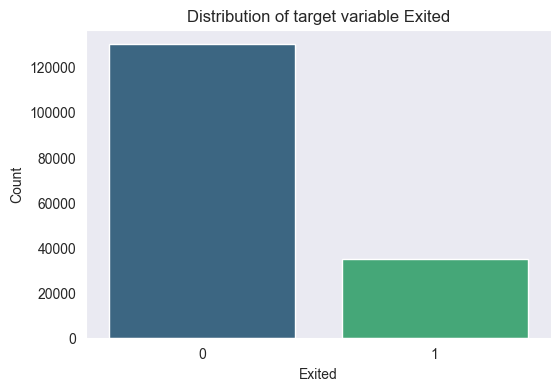

In [26]:
# Target distribution (class balance)
target_counts = train_data["Exited"].value_counts().sort_index()
target_props = train_data["Exited"].value_counts(normalize=True).sort_index()

print("Exited value counts:")
print(target_counts)

print("\nExited proportions:")
print(target_props)

plt.figure(figsize=(6, 4))
sns.countplot(x="Exited", data=train_data, palette="viridis")
plt.title("Distribution of target variable Exited")
plt.xlabel("Exited")
plt.ylabel("Count")
plt.show()

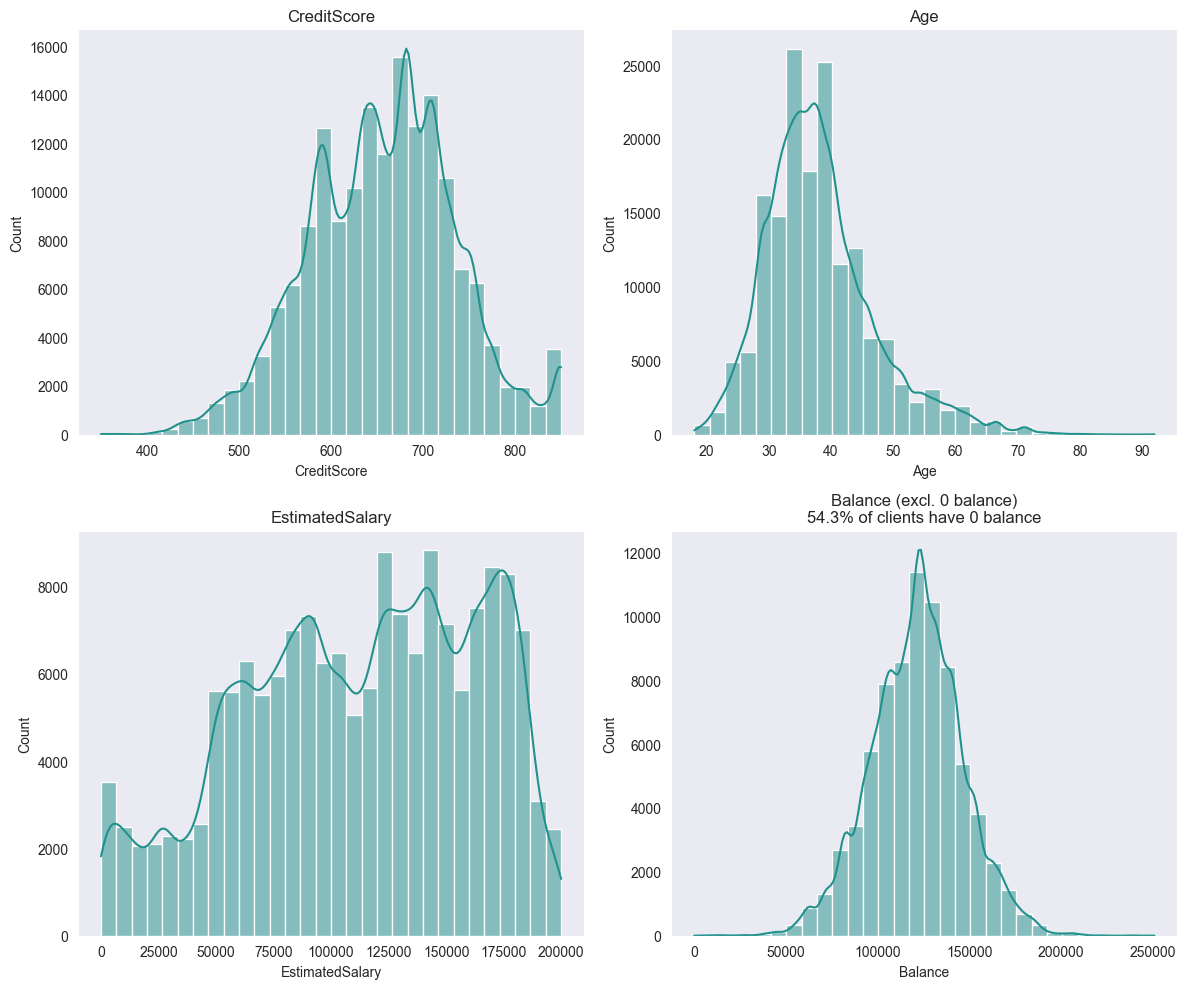

In [27]:
# Numeric feature distributions (excluding Tenure and NumOfProducts)
numeric_cols = ["CreditScore", "Age", "Balance", "EstimatedSalary"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

viridis_c = sns.color_palette("viridis", n_colors=1)[0]
for i, col in enumerate(["CreditScore", "Age", "EstimatedSalary"]):
    sns.histplot(train_data[col], kde=True, bins=30, ax=axes[i], color=viridis_c)
    axes[i].set_title(col)

# Balance: many zeros — show distribution of positive balances only, and note % with 0
pct_zero = (train_data["Balance"] == 0).mean() * 100
balance_positive = train_data.loc[train_data["Balance"] > 0, "Balance"]
sns.histplot(balance_positive, kde=True, bins=30, ax=axes[3], color=viridis_c)
axes[3].set_title(f"Balance (excl. 0 balance)\n{pct_zero:.1f}% of clients have 0 balance")

plt.tight_layout()
plt.show()

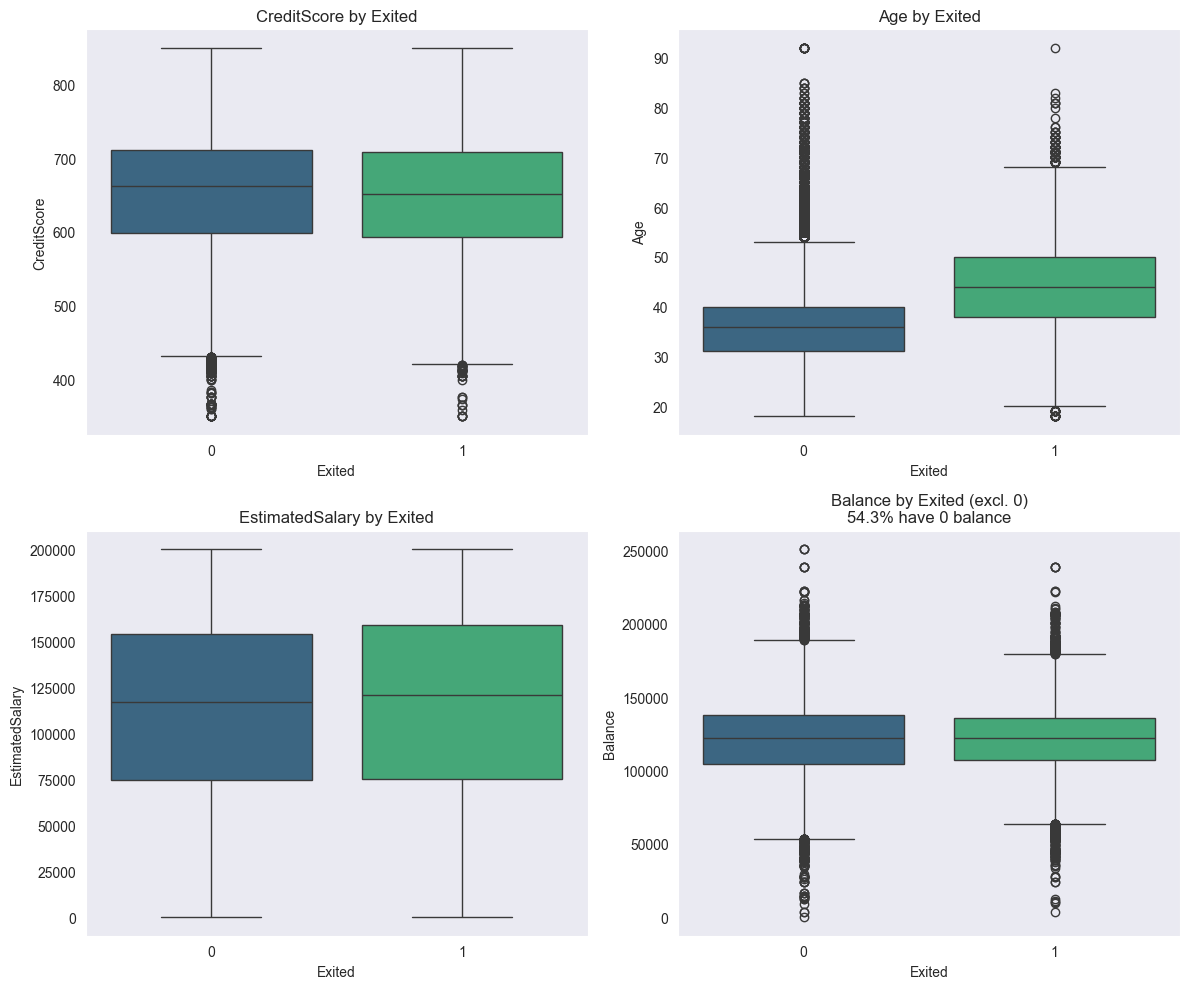

In [28]:
# Numeric features vs Exited (excluding Tenure and NumOfProducts)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(["CreditScore", "Age", "EstimatedSalary"]):
    sns.boxplot(data=train_data, x="Exited", y=col, ax=axes[i], palette="viridis")
    axes[i].set_title(f"{col} by Exited")

# Balance: boxplot for positive balances only so distribution is visible
pct_zero = (train_data["Balance"] == 0).mean() * 100
balance_df = train_data[train_data["Balance"] > 0][["Balance", "Exited"]]
sns.boxplot(data=balance_df, x="Exited", y="Balance", ax=axes[3], palette="viridis")
axes[3].set_title(f"Balance by Exited (excl. 0)\n{pct_zero:.1f}% have 0 balance")

plt.tight_layout()
plt.show()

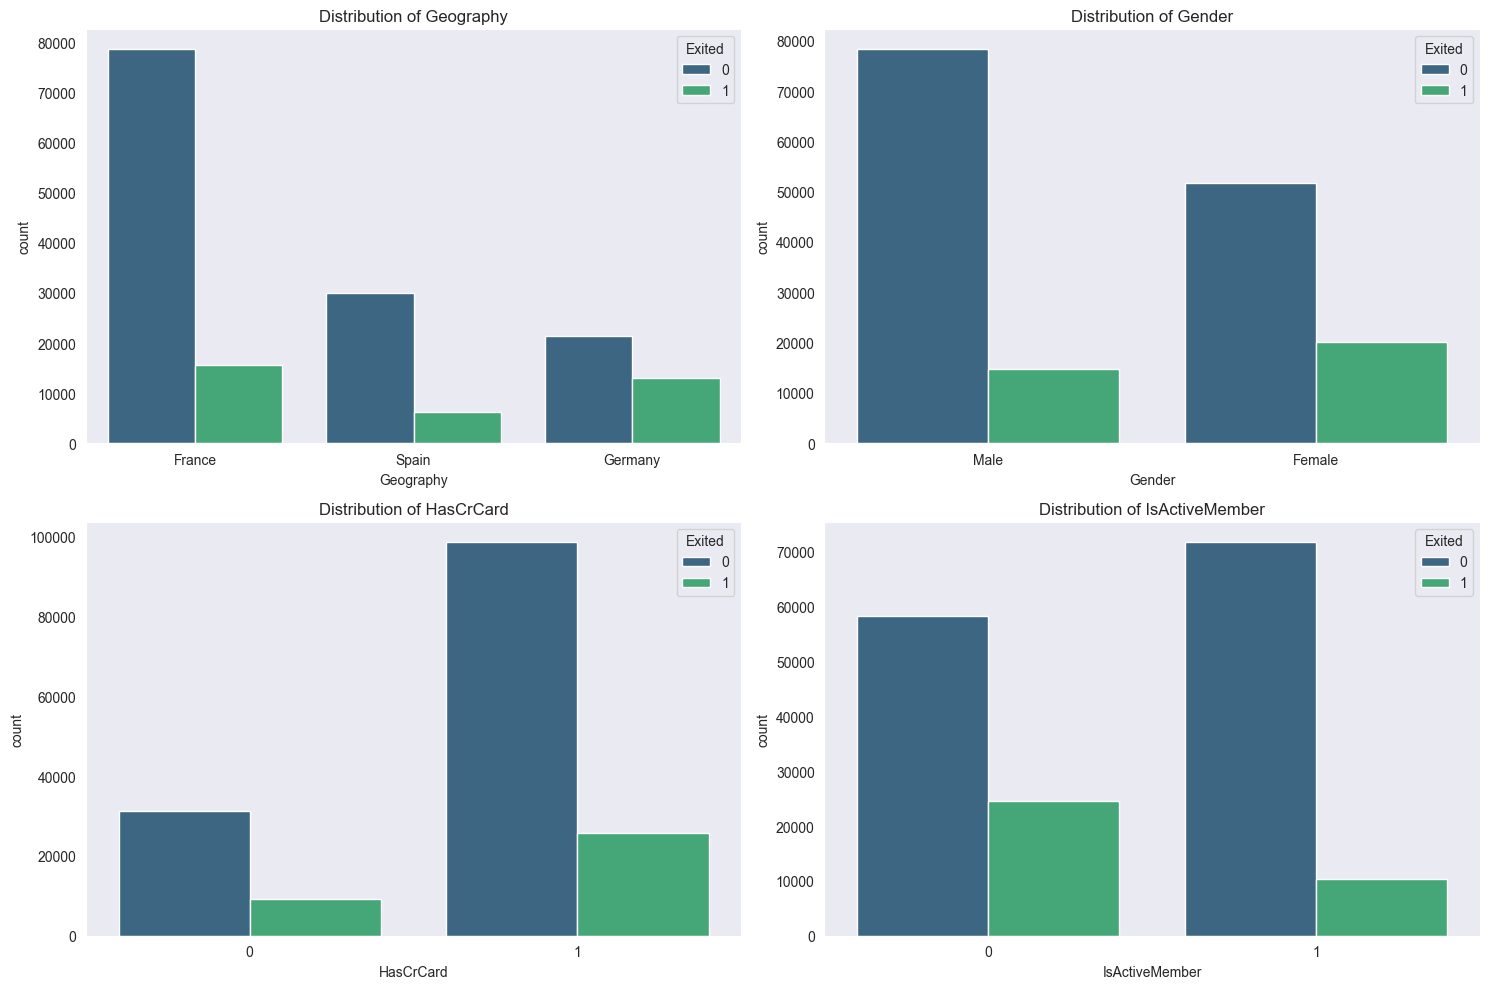

In [29]:
categorical_columns = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember']
# rows of subplots
num_rows = len(categorical_columns) // 2 + len(categorical_columns) % 2

plt.figure(figsize=(15, 5 * num_rows))
for i, column in enumerate(categorical_columns, 1):
    plt.subplot(num_rows, 2, i)
    sns.countplot(data=train_data, x=column, hue='Exited', palette='viridis') 
    plt.title(f'Distribution of {column}')

plt.tight_layout()
plt.show()

In [30]:
# Churn rate by categorical features
for col in categorical_columns:
    churn_rate = (
        train_data
        .groupby(col)["Exited"]
        .mean()
        .sort_values(ascending=False)
    )
    print(f"\nChurn rate by {col}:")
    print(churn_rate)


Churn rate by Geography:
Geography
Germany    0.378952
Spain      0.172176
France     0.165282
Name: Exited, dtype: float64

Churn rate by Gender:
Gender
Female    0.279687
Male      0.159055
Name: Exited, dtype: float64

Churn rate by HasCrCard:
HasCrCard
0    0.227429
1    0.206433
Name: Exited, dtype: float64

Churn rate by IsActiveMember:
IsActiveMember
0    0.297086
1    0.125345
Name: Exited, dtype: float64


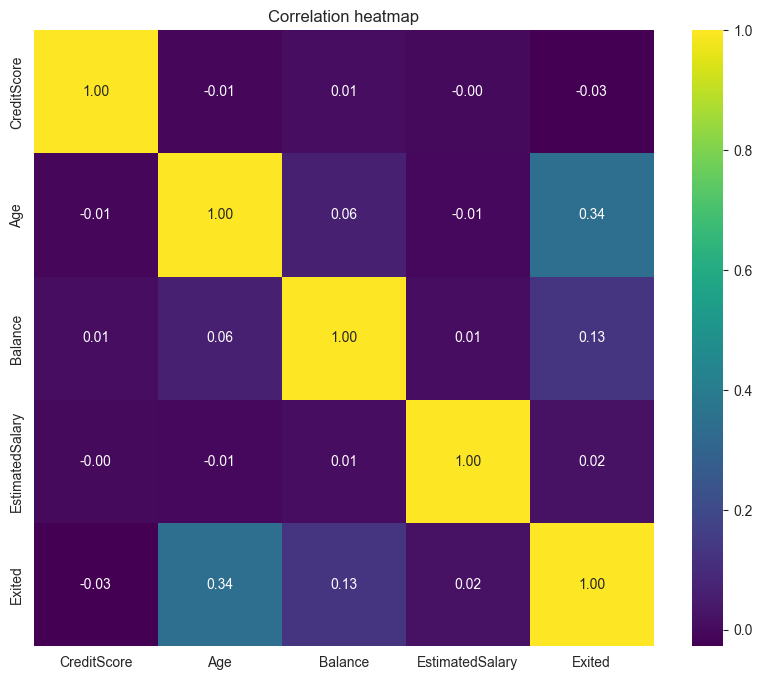

In [31]:
# Correlation heatmap (numeric features + target)
corr_cols = numeric_cols + ["Exited"]

plt.figure(figsize=(10, 8))
corr = train_data[corr_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="viridis")
plt.title("Correlation heatmap")
plt.show()